In [1]:
import sys
sys.path.append("../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import portfolio as pf
import risk

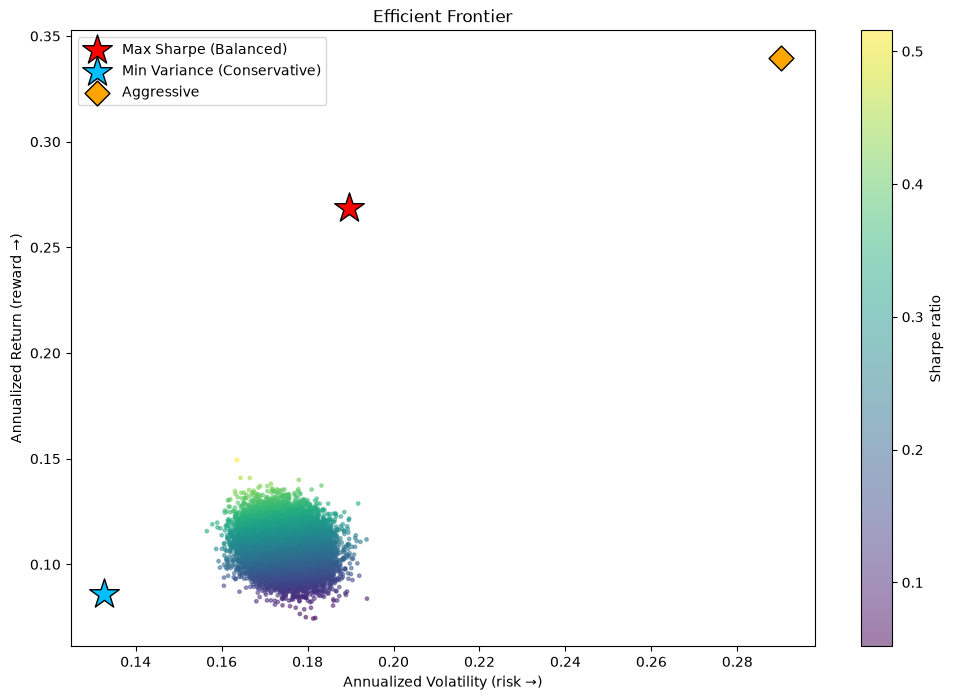

In [4]:
# Build universe + frontier
rets, dropped = pf.build_universe_returns()
mc = pf.monte_carlo_frontier(rets, n_portfolios=20000)
opt = pf.optimal_portfolios(rets)
profiles = pf.build_investor_portfolios(rets)

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Monte Carlo cloud, colored by Sharpe
sc = ax.scatter(mc["vol"], mc["ret"], c=mc["sharpe"],
                cmap="viridis", s=6, alpha=0.5)
plt.colorbar(sc, label="Sharpe ratio")

# 2. Mark the optimal portfolios
ax.scatter(opt["max_sharpe"]["vol"], opt["max_sharpe"]["ret"],
           marker="*", s=500, color="red", edgecolor="black",
           label="Max Sharpe (Balanced)", zorder=5)
ax.scatter(opt["min_variance"]["vol"], opt["min_variance"]["ret"],
           marker="*", s=500, color="deepskyblue", edgecolor="black",
           label="Min Variance (Conservative)", zorder=5)

# 3. Mark the Aggressive profile
agg = profiles["Aggressive"]["metrics"]
ax.scatter(agg["ann_vol"], agg["ann_return"],
           marker="D", s=160, color="orange", edgecolor="black",
           label="Aggressive", zorder=5)

ax.set_xlabel("Annualized Volatility (risk →)")
ax.set_ylabel("Annualized Return (reward →)")
ax.set_title("Efficient Frontier")
ax.legend()
plt.show()